## 📊 Data Profiler 

### 📚 Part B: Data Acquisition

#### 5️⃣ Import datasets from different sources:  
#### 📂 Load CSV file using Pandas.   

In [2]:
import pandas as pd

df_csv = pd.read_csv("retail_customer_transactions.csv")

print(df_csv.shape)
df_csv.head()

(1500, 11)


,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Category,Total_Purchases,Avg_Purchase_Value,Payment_Type,Satisfaction_Score,Subscription_Status
0,1,58,Male,Ahmedabad,117196,Home Decor,16,119.37,UPI,1.4,Active
1,2,65,Male,Surat,75302,Electronics,2,55.91,Debit Card,3.0,Active
2,3,30,Female,Bengaluru,78878,Home Decor,52,435.96,Debit Card,3.8,Active
3,4,39,Female,Delhi,48221,Beauty,7,55.45,Credit Card,2.4,Active
4,5,34,Male,Kolkata,90284,Clothing,60,195.48,Net Banking,2.2,Active


In [3]:
df_csv.tail()

,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Category,Total_Purchases,Avg_Purchase_Value,Payment_Type,Satisfaction_Score,Subscription_Status
1495,1496,59,Male,Bengaluru,110392,Sports,12,29.71,Net Banking,2.1,Active
1496,1497,35,Male,Bengaluru,116119,Clothing,58,452.54,Net Banking,2.2,Active
1497,1498,31,Male,Bengaluru,96765,Sports,30,58.15,Credit Card,2.3,Active
1498,1499,58,Male,Bengaluru,82691,Clothing,29,50.86,Debit Card,1.4,Active
1499,1500,55,Male,Surat,83862,Home Decor,37,14.71,Cash,4.4,Active


In [4]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1500 non-null   int64  
 1   Age                  1500 non-null   int64  
 2   Gender               1500 non-null   object 
 3   City                 1500 non-null   object 
 4   Annual_Income        1500 non-null   int64  
 5   Purchase_Category    1500 non-null   object 
 6   Total_Purchases      1500 non-null   int64  
 7   Avg_Purchase_Value   1500 non-null   float64
 8   Payment_Type         1500 non-null   object 
 9   Satisfaction_Score   1500 non-null   float64
 10  Subscription_Status  1500 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


#### 📂 Parse a JSON file.  

In [5]:
import json

with open("customer_profiles.json") as file_obj:
    profile_records = json.load(file_obj)

df_json = pd.json_normalize(profile_records)
df_json.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          30 non-null     int64 
 1   Full_Name            30 non-null     object
 2   Age                  30 non-null     int64 
 3   Gender               30 non-null     object
 4   Annual_Income        30 non-null     int64 
 5   Total_Purchases      30 non-null     int64 
 6   Payment_Type         30 non-null     object
 7   Subscription_Status  30 non-null     object
dtypes: int64(4), object(4)
memory usage: 2.0+ KB


In [6]:
df_json.head()

,Customer_ID,Full_Name,Age,Gender,Annual_Income,Total_Purchases,Payment_Type,Subscription_Status
0,1,Customer_001,25,Female,104230,13,Net Banking,Inactive
1,2,Customer_002,18,Female,118901,27,Net Banking,Inactive
2,3,Customer_003,49,Male,63075,33,Cash,Inactive
3,4,Customer_004,59,Female,54629,56,Net Banking,Active
4,5,Customer_005,39,Female,108846,36,Net Banking,Inactive


In [7]:
df_json.tail()

,Customer_ID,Full_Name,Age,Gender,Annual_Income,Total_Purchases,Payment_Type,Subscription_Status
25,26,Customer_026,62,Female,52747,18,Net Banking,Inactive
26,27,Customer_027,21,Male,27355,41,Online Wallet,Inactive
27,28,Customer_028,52,Female,77425,60,Online Wallet,Active
28,29,Customer_029,48,Male,118281,5,Online Wallet,Inactive
29,30,Customer_030,70,Male,39715,38,Online Wallet,Active


#### 🗄 Connect to a SQL table and fetch records.  

In [8]:
import sqlite3

conn = sqlite3.connect("retail_customers.db")
cur = conn.cursor()

cur.execute("""
CREATE TABLE IF NOT EXISTS customer_records (
    Customer_ID INTEGER PRIMARY KEY,
    Age INTEGER,
    Gender TEXT,
    Annual_Income INTEGER,
    Total_Purchases INTEGER,
    Payment_Type TEXT,
    Subscription_Status TEXT
)
""")

rows_to_insert = [
    (1, 27, "Female", 39450, 32, "UPI", "Active"),
    (2, 34, "Female", 51722, 5, "Net Banking", "Inactive"),
    (3, 45, "Female", 62417, 26, "Credit Card", "Active"),
    (4, 31, "Male", 44412, 8, "Cash", "Inactive"),
    (5, 38, "Female", 55288, 27, "Debit Card", "Inactive"),
]
cur.executemany("INSERT OR IGNORE INTO customer_records VALUES (?,?,?,?,?,?,?)", rows_to_insert)
conn.commit()

df_sql = pd.read_sql_query("SELECT * FROM customer_records", conn)
df_sql.head()

,Customer_ID,Age,Gender,Annual_Income,Total_Purchases,Payment_Type,Subscription_Status
0,1,27,Female,39450,32,UPI,Active
1,2,34,Female,51722,5,Net Banking,Inactive
2,3,45,Female,62417,26,Credit Card,Active
3,4,31,Male,44412,8,Cash,Inactive
4,5,38,Female,55288,27,Debit Card,Inactive


In [9]:
df_sql.tail()

,Customer_ID,Age,Gender,Annual_Income,Total_Purchases,Payment_Type,Subscription_Status
0,1,27,Female,39450,32,UPI,Active
1,2,34,Female,51722,5,Net Banking,Inactive
2,3,45,Female,62417,26,Credit Card,Active
3,4,31,Male,44412,8,Cash,Inactive
4,5,38,Female,55288,27,Debit Card,Inactive


In [10]:
df_sql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          5 non-null      int64 
 1   Age                  5 non-null      int64 
 2   Gender               5 non-null      object
 3   Annual_Income        5 non-null      int64 
 4   Total_Purchases      5 non-null      int64 
 5   Payment_Type         5 non-null      object
 6   Subscription_Status  5 non-null      object
dtypes: int64(4), object(3)
memory usage: 412.0+ bytes


#### 🌐 Fetch data from an API (e.g., random user API or dummy REST API).

In [11]:
import requests

resp = requests.get("https://randomuser.me/api/?results=20").json()
df_api = pd.json_normalize(resp["results"])
df_api[["gender", "email", "location.city"]].head()

,gender,email,location.city
0,female,romee.schaaphok@example.com,Stokkum
1,female,lenicia.goncalves@example.com,Sinop
2,male,davut.gumuspala@example.com,Hatay
3,male,gerry.rogers@example.com,Nottingham
4,male,mhmdaaly.mrdy@example.com,خمینی‌شهر


In [12]:
df_api[["gender", "email", "location.city"]].tail()

,gender,email,location.city
15,male,joe.coleman@example.com,Burbank
16,female,angelina.dumas@example.com,Lyon
17,male,dylan.lo@example.com,Sandy Lake
18,female,jara.kools@example.com,Den Oever
19,male,sphr.kmyrn@example.com,قائم‌شهر


In [13]:
df_api[["gender", "email", "location.city"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         20 non-null     object
 1   email          20 non-null     object
 2   location.city  20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes


#### 🗂️ Merged the data :- 

In [14]:
combined_df = pd.concat([df_csv, df_json, df_sql], ignore_index=True)

combined_df = combined_df.merge(
    df_api[["gender", "email", "location.city"]],
    left_index=True, right_index=True, how="left"
)

combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1535 entries, 0 to 1534
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1535 non-null   int64  
 1   Age                  1535 non-null   int64  
 2   Gender               1535 non-null   object 
 3   City                 1500 non-null   object 
 4   Annual_Income        1535 non-null   int64  
 5   Purchase_Category    1500 non-null   object 
 6   Total_Purchases      1535 non-null   int64  
 7   Avg_Purchase_Value   1500 non-null   float64
 8   Payment_Type         1535 non-null   object 
 9   Satisfaction_Score   1500 non-null   float64
 10  Subscription_Status  1535 non-null   object 
 11  Full_Name            30 non-null     object 
 12  gender               20 non-null     object 
 13  email                20 non-null     object 
 14  location.city        20 non-null     object 
dtypes: float64(2), int64(4), object(9)
mem

In [15]:
combined_df.head()

,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Category,Total_Purchases,Avg_Purchase_Value,Payment_Type,Satisfaction_Score,Subscription_Status,Full_Name,gender,email,location.city
0,1,58,Male,Ahmedabad,117196,Home Decor,16,119.37,UPI,1.4,Active,NaN,female,romee.schaaphok@example.com,Stokkum
1,2,65,Male,Surat,75302,Electronics,2,55.91,Debit Card,3.0,Active,NaN,female,lenicia.goncalves@example.com,Sinop
2,3,30,Female,Bengaluru,78878,Home Decor,52,435.96,Debit Card,3.8,Active,NaN,male,davut.gumuspala@example.com,Hatay
3,4,39,Female,Delhi,48221,Beauty,7,55.45,Credit Card,2.4,Active,NaN,male,gerry.rogers@example.com,Nottingham
4,5,34,Male,Kolkata,90284,Clothing,60,195.48,Net Banking,2.2,Active,NaN,male,mhmdaaly.mrdy@example.com,خمینی‌شهر


In [16]:
combined_df.tail()

,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Category,Total_Purchases,Avg_Purchase_Value,Payment_Type,Satisfaction_Score,Subscription_Status,Full_Name,gender,email,location.city
1530,1,27,Female,NaN,39450,NaN,32,NaN,UPI,NaN,Active,NaN,NaN,NaN,NaN
1531,2,34,Female,NaN,51722,NaN,5,NaN,Net Banking,NaN,Inactive,NaN,NaN,NaN,NaN
1532,3,45,Female,NaN,62417,NaN,26,NaN,Credit Card,NaN,Active,NaN,NaN,NaN,NaN
1533,4,31,Male,NaN,44412,NaN,8,NaN,Cash,NaN,Inactive,NaN,NaN,NaN,NaN
1534,5,38,Female,NaN,55288,NaN,27,NaN,Debit Card,NaN,Inactive,NaN,NaN,NaN,NaN


### 🧹 Part C: Data Understanding & Cleaning

 #### 6️⃣ Perform initial exploration:  
* 🔍 Use .head(), .info(), .describe() to explore.  
* 🔍 Identify missing values and duplicates.  

In [50]:
print(combined_df.head())
print(combined_df.info())
print(combined_df.describe(include="all"))
print(combined_df.isnull().sum())
print(combined_df.duplicated().sum())

   Customer_ID  Age  Gender       City  Annual_Income Purchase_Category  \
0            1   58    Male  Ahmedabad         117196        Home Decor   
1            2   65    Male      Surat          75302       Electronics   
2            3   30  Female  Bengaluru          78878        Home Decor   
3            4   39  Female      Delhi          48221            Beauty   
4            5   34    Male    Kolkata          90284          Clothing   

   Total_Purchases  Avg_Purchase_Value Payment_Type  Satisfaction_Score  \
0               16              119.37          UPI                 1.4   
1                2               55.91   Debit Card                 3.0   
2               52              435.96   Debit Card                 3.8   
3                7               55.45  Credit Card                 2.4   
4               60              195.48  Net Banking                 2.2   

  Subscription_Status Full_Name  gender                          email  \
0              Active   

#### 7️⃣ Apply data cleaning:  
* 🧩 Handle missing data (imputation or removal).  
* 🧩 Correct inconsistent data types.  
* 🧩 Drop irrelevant columns.  

In [18]:
combined_df = combined_df.dropna(subset=["Age", "Annual_Income"], how="any")
combined_df["Total_Purchases"] = combined_df["Total_Purchases"].fillna(0).astype(int)
combined_df["Age"] = combined_df["Age"].astype(int)
combined_df["Annual_Income"] = combined_df["Annual_Income"].astype(int)
combined_df = combined_df.drop_duplicates()
combined_df = combined_df.drop(columns=["Unused_Col"], errors="ignore")

print("After cleaning:", combined_df.shape)

After cleaning: (1535, 15)


In [19]:
print("Information of the combined data:-")
print("---------------------------------------------------")
combined_df.info()

Information of the combined data:-
---------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1535 entries, 0 to 1534
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1535 non-null   int64  
 1   Age                  1535 non-null   int64  
 2   Gender               1535 non-null   object 
 3   City                 1500 non-null   object 
 4   Annual_Income        1535 non-null   int64  
 5   Purchase_Category    1500 non-null   object 
 6   Total_Purchases      1535 non-null   int64  
 7   Avg_Purchase_Value   1500 non-null   float64
 8   Payment_Type         1535 non-null   object 
 9   Satisfaction_Score   1500 non-null   float64
 10  Subscription_Status  1535 non-null   object 
 11  Full_Name            30 non-null     object 
 12  gender               20 non-null     object 
 13  email                20 non-null     object 
 14  l

### 📈 Part D: Exploratory Data Analysis (EDA)  
#### 8️⃣ Perform Univariate Analysis:  
* 📊 Distribution plots of Age, Income, and Purchases.  

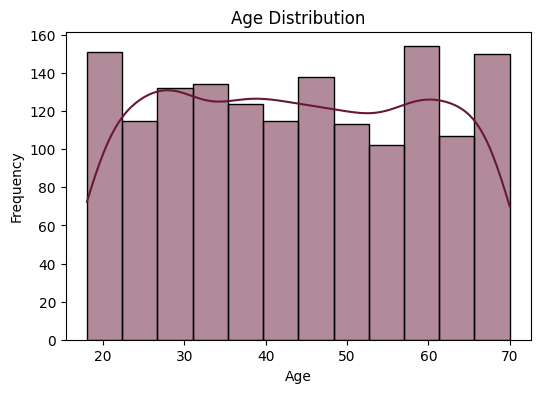

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Plot of Age
plt.figure(figsize=(6,4))
sns.histplot(combined_df["Age"], kde=True,color="#671839"  )
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

##### 📊 Insight: Age is fairly evenly distributed between 18 and 70 years, with no dominant age group. 
##### ✅ Conclusion: The dataset includes customers from a wide range of ages. 

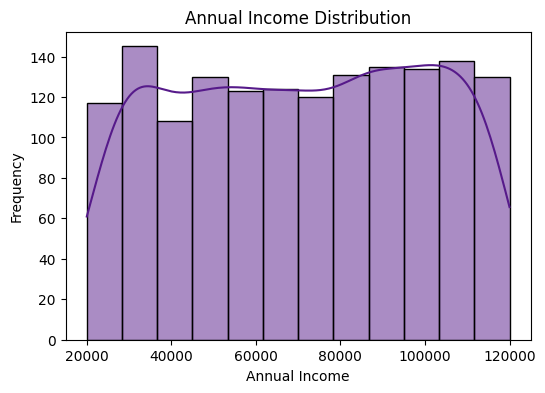

In [35]:
# Distribution Plot of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(combined_df["Annual_Income"], kde=True,color="#561A8A")
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

##### 📈 Annual income is spread across the full income range without a strong peak.
##### ✅ Customers have diverse income levels. 💵

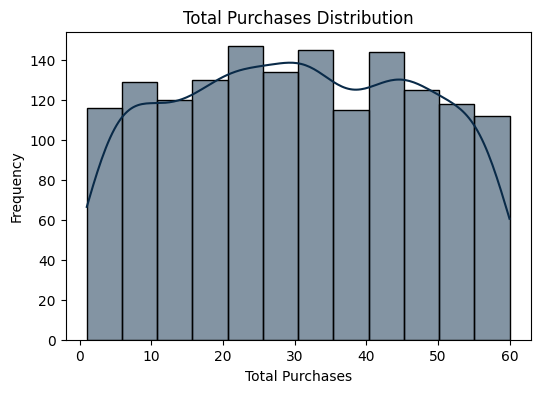

In [36]:
# Distribution Plot of Total Purchases
plt.figure(figsize=(6,4))
sns.histplot(combined_df["Total_Purchases"], kde=True,color="#092A48")
plt.title("Total Purchases Distribution")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

##### 📦 Insight: Total purchases are distributed across the range with no single purchase level dominating. 
##### ✅ Conclusion: Customers show varied purchasing behavior. 

### 9️⃣ Perform Bivariate Analysis:  
* 👥 Relationship between Gender & Purchases.
* 💰 Relationship between Income & Churn.  

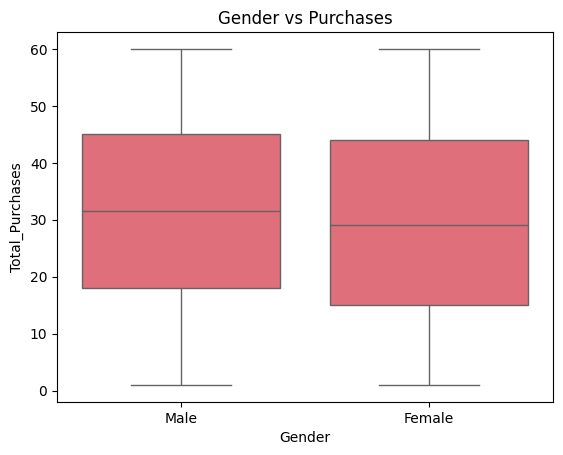

In [43]:
sns.boxplot(x="Gender", y="Total_Purchases", data=combined_df , color="#F05D6C")
plt.title("Gender vs Purchases")
plt.show()

##### 📦 Insight: Male and female customers have a similar median of around 30 purchases, and both groups have a similar spread (about 1–60 purchases).
##### ✅ Conclusion: There is no clear difference in total purchases between male and female customers.

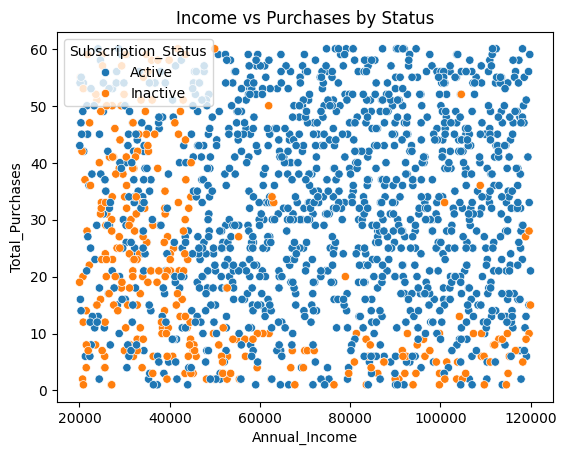

In [44]:
sns.scatterplot(x="Annual_Income", y="Total_Purchases", hue="Subscription_Status", data=combined_df)
plt.title("Income vs Purchases by Status")
plt.show()

##### 📈 Insight: Annual income ranges from about 20,000 to 120,000, while purchases range from 1 to 60, with points spread across the entire plot.
##### ✅ Conclusion: There is no clear relationship between annual income and total purchases from this scatter plot alone.

### 🔟 Perform Multivariate Analysis:  
* 📊 Correlation heatmap of all numerical variables.  
* 📊 Pair plots to identify feature interactions.  

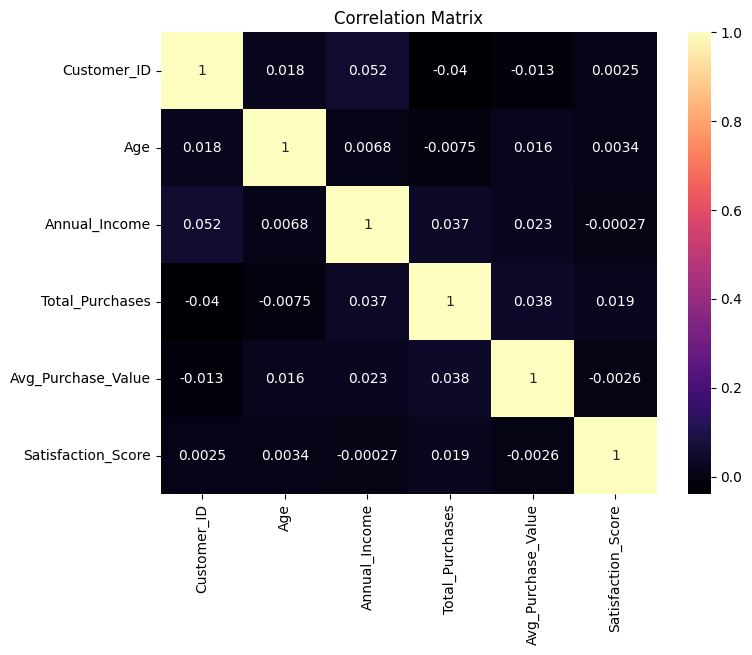

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(combined_df.corr(numeric_only=True), annot=True, cmap="magma")
plt.title("Correlation Matrix")
plt.show()

##### 📦 Insight: The strongest correlation visible is only ≈0.05 (Customer_ID vs Annual Income). Age vs Total Purchases is basically ≈−0.01, which is indistinguishable from zero.
##### ✅ Conclusion: Since every value sits between −0.04 and 0.05, the heatmap proves there is no linear relationship between customer attributes and buying behavior.


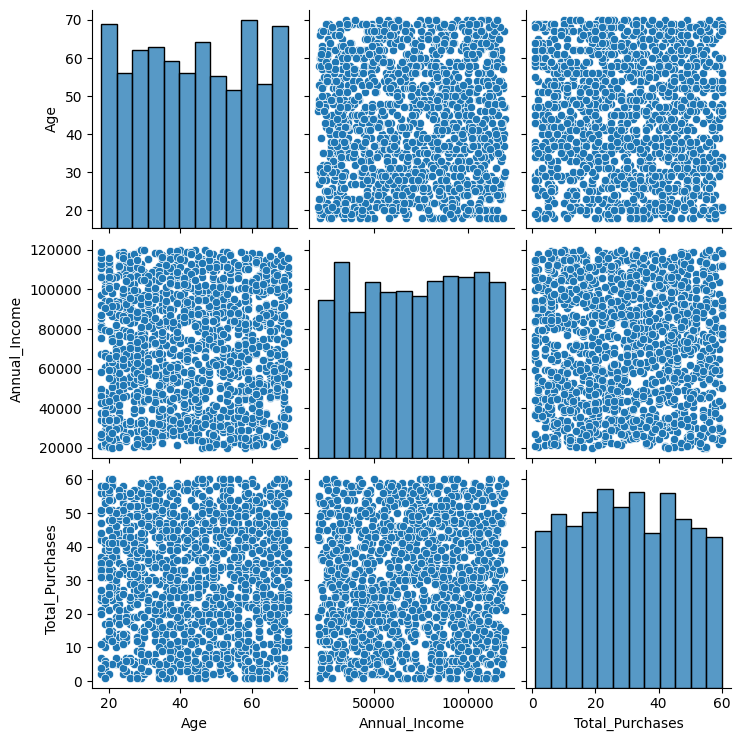

In [46]:
sns.pairplot(combined_df[["Age", "Annual_Income", "Total_Purchases"]])
plt.show()

##### 📦 Insight: The scatter plots are just square clouds of dots. For example, Age (20–70) vs Annual Income ($20k–$120k) shows a perfectly even spread, and Purchases scatter evenly across the axis.
##### ✅ Conclusion: The uniform scatter proves independence — Age, Income, and Purchases don’t cluster or trend together; they’re spread randomly across their ranges.

### 🔍 Part E: Data Profiling  
#### 1️⃣1️⃣ Generate a Pandas Profiling Report that summarizes:  
- ❌ Missing values.  
- 📊 Descriptive statistics.  
- 🔗 Correlations.  
- ⚠️ Warnings on potential data quality issues.

In [51]:
from ydata_profiling import ProfileReport

report = ProfileReport(combined_df, title="Retail Customer Profiling Report", explorative=True)
report.to_file("retail_profiling_report.html")
print("Report saved.")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 33.28it/s]

Report saved.
